# Density Comparison in different Discipline Groups, Age Groups and Gender

#### Data loading


In [1]:
import sys
from pathlib import Path

# Path to the parent folder (where util is)
parent_path = Path().resolve().parent.parent
sys.path.append(str(parent_path))
import util
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import help_functions as hp
import tueplots as tue

data = util.load_data(path_file='C:\\Users\\Mattis\\OneDrive\\Kogni\\DataLiteracyProject\\Data-Literacy\\data_csv\\final_data_iaaf_scores_neu.csv') 

data.head()


,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,iaaf_score
0,2017,W,Frauen,100 m,10.95,"+1,3",Gina Lueckenkemper,1996,LG Olympia Dortmund,05.08.,London/GBR,1211
1,2017,W,Frauen,100 m,11.06,"+1,8",Rebekka Haase,1993,LV 90 Erzgebirge,25.05.,Zeulenroda,1187
2,2017,W,Frauen,100 m,11.14,"-0,2",Lisa Mayer,1996,Sprintteam Wetzlar,27.08.,Berlin,1169
3,2017,W,Frauen,100 m,11.24,"+0,3",Tatjana Pinto,1992,LC Paderborn,15.07.,Ninove/BEL,1148
4,2017,W,Frauen,100 m,11.25,"+1,9",Sina Mayer,1995,LAZ Zweibruecken,11.06.,Regensburg,1146


#### Group determiantions

In [37]:
# The number of top entries to collect
num_entries = 40

# Exclude outliers that are not explainable

data = data[(data["iaaf_score"] < 1380) & (data["iaaf_score"] > 20)]

# Define Discipline groups NOTE: Only the ones with clear data

mapping_dict = {
    **{d: 'Run' for d in ['800 m', '1500 m', '3000 m', '5000 m']},
    **{d: 'Sprint' for d in ['100 m', '200 m', '400 m', '400m Huerden']},
    **{d: 'Throw' for d in ['Kugelstoss', 'Diskuswurf', 'Speerwurf', 'Hammerwurf']}, 
    **{d: 'Jump' for d in ['Hochsprung', 'Stabhochsprung', 'Weitsprung', 'Dreisprung']}
}
data['disziplingruppe'] = data['disziplin'].map(mapping_dict)
data = data.dropna(subset=['disziplingruppe'])

#Define Adult age group
data['altersklasse'] = data['altersklasse'].replace({'Maenner': 'Adult', 'Frauen': 'Adult', '16': 'U16', '18': 'U18', '20': 'U20', '14': 'AK14'})

# Collect top entries
top_raw_all = hp.collect_top_entries(data, num_entries=num_entries)

### Plot 1: Differences for ranks 2001-2004 to 2021-2024

In [19]:
# Parameters
ranks = range(1, num_entries + 1)

# Store all results
results_std_mean = []
results_ranks_age = []
results_ranks_disc_age = []
results_ranks_all = []

# Unique events and genders
events = top_raw_all["disziplin"].unique()
genders = ["M", "W"]
age_groups = ["U18", "U20", "Adult"]

top_raw_all = top_raw_all[top_raw_all["altersklasse"].isin(age_groups)]

top_raw_all = top_raw_all.sort_values(["jahr", "iaaf_score"], ascending=[True, False])

top_raw_all['rank'] = top_raw_all.groupby(["disziplin", "jahr", "geschlecht", "altersklasse"])["iaaf_score"].rank(ascending=False, method='first')

grouped = top_raw_all.groupby(["disziplingruppe", "geschlecht", "altersklasse"])

# RANKS AND MEAN+STD FOR AGE GROUP AND DISCIPLINE GROUPS

for (dis_group, gender, age), subgroup in grouped:

    for r in range(1, num_entries+1):
        start_rank_vals = []
        end_rank_vals = []

        for event in subgroup['disziplin'].unique():
            subsub = subgroup[subgroup['disziplin'] == event]
            S_gr = subsub.pivot_table(index="jahr", columns="rank", values="iaaf_score")

            start_rank_vals.append(S_gr.loc[2001:2004, r].mean())
            end_rank_vals.append(S_gr.loc[2021:2024, r].mean())
        
        mean_start_r = np.mean(start_rank_vals)
        mean_end_r = np.mean(end_rank_vals)
        diff_r = (mean_end_r - mean_start_r) / mean_start_r * 100

        results_ranks_disc_age.append({
            "Group": dis_group,
            "geschlecht": gender,
            "altersklasse": age,
            "mean_diff_perc": diff_r,
            "rank": r
        })

    start_values_pool = []
    end_values_pool = []

    for event in subgroup['disziplin'].unique():
        subsub = subgroup[subgroup['disziplin'] == event]
        S_gr = subsub.pivot_table(index="jahr", columns="rank", values="iaaf_score")
        
        start = S_gr.loc[2001:2004].values.flatten()
        end = S_gr.loc[2021:2024].values.flatten()

        start_values_pool.extend(start[~np.isnan(start)])
        end_values_pool.extend(end[~np.isnan(end)])


    mean_diff = (np.mean(end_values_pool) - np.mean(start_values_pool)) / np.mean(start_values_pool) * 100
    std_diff = (np.std(end_values_pool) - np.std(start_values_pool)) / np.std(start_values_pool) * 100
    
    results_std_mean.append({
        "Group": dis_group,
        "geschlecht": gender,
        "altersklasse": age,
        "mean_diff_perc": mean_diff,
        "std_diff_perc": std_diff
    })

results_std_mean = pd.DataFrame(results_std_mean)

results_ranks_disc_age = pd.DataFrame(results_ranks_disc_age)

# ONLY FOR AGE GROUPS

grouped_age = top_raw_all.groupby(["geschlecht", "altersklasse"])

for (gender, age), subgroup in grouped_age:
    
    for r in range(1, num_entries+1):
        start_rank_vals = []
        end_rank_vals = []

        for event in subgroup['disziplin'].unique():
            subsub = subgroup[subgroup['disziplin'] == event]
            subsub = subsub.copy()
            subsub['rank'] = subsub.groupby("jahr")["iaaf_score"].rank(ascending=False, method='first')
            S_gr = subsub.pivot_table(index="jahr", columns="rank", values="iaaf_score")
            
            start_rank_vals.append(S_gr.loc[2001:2004, r].mean())
            end_rank_vals.append(S_gr.loc[2021:2024, r].mean())

        mean_start_r = np.mean(start_rank_vals)
        mean_end_r = np.mean(end_rank_vals)
        diff_r = (mean_end_r - mean_start_r) / mean_start_r * 100

        results_ranks_age.append({
            "geschlecht": gender,
            "altersklasse": age,
            "mean_diff_perc": diff_r,
            "rank": r
        })

results_ranks_age = pd.DataFrame(results_ranks_age)

# RANKS FOR ALL DATA

for r in range(1, num_entries+1):
        start_rank_vals = []
        end_rank_vals = []

        for event in top_raw_all['disziplin'].unique():
            subsub = top_raw_all[top_raw_all['disziplin'] == event]
            S_gr = subsub.pivot_table(index="jahr", columns="rank", values="iaaf_score")

            start_rank_vals.append(S_gr.loc[2001:2004, r].mean())
            end_rank_vals.append(S_gr.loc[2021:2024, r].mean())
        
        mean_start_r = np.mean(start_rank_vals)
        mean_end_r = np.mean(end_rank_vals)
        diff_r = (mean_end_r - mean_start_r) / mean_start_r * 100

        results_ranks_all.append({
            "mean_diff_perc": diff_r,
            "rank": r
        })

results_ranks_all = pd.DataFrame(results_ranks_all)


Diskuswurf M Adult 1 -8.051077703314617
Hochsprung M Adult 1 -8.051077703314617
Speerwurf M Adult 1 -8.051077703314617
Stabhochsprung M Adult 1 -8.051077703314617
400 m M Adult 1 -8.051077703314617
800 m M Adult 1 -8.051077703314617
Hammerwurf M Adult 1 -8.051077703314617
Weitsprung M Adult 1 -8.051077703314617
Dreisprung M Adult 1 -8.051077703314617
3000 m M Adult 1 -8.051077703314617
Kugelstoss M Adult 1 -8.051077703314617
1500 m M Adult 1 -8.051077703314617
100 m M Adult 1 -8.051077703314617
200 m M Adult 1 -8.051077703314617
5000 m M Adult 1 -8.051077703314617
Diskuswurf M Adult 2 -0.1929598047700786
Hochsprung M Adult 2 -0.1929598047700786
Speerwurf M Adult 2 -0.1929598047700786
Stabhochsprung M Adult 2 -0.1929598047700786
400 m M Adult 2 -0.1929598047700786
800 m M Adult 2 -0.1929598047700786
Hammerwurf M Adult 2 -0.1929598047700786
Weitsprung M Adult 2 -0.1929598047700786
Dreisprung M Adult 2 -0.1929598047700786
3000 m M Adult 2 -0.1929598047700786
Kugelstoss M Adult 2 -0.192959

## Plotting: Standard Deviation and Mean Evolution

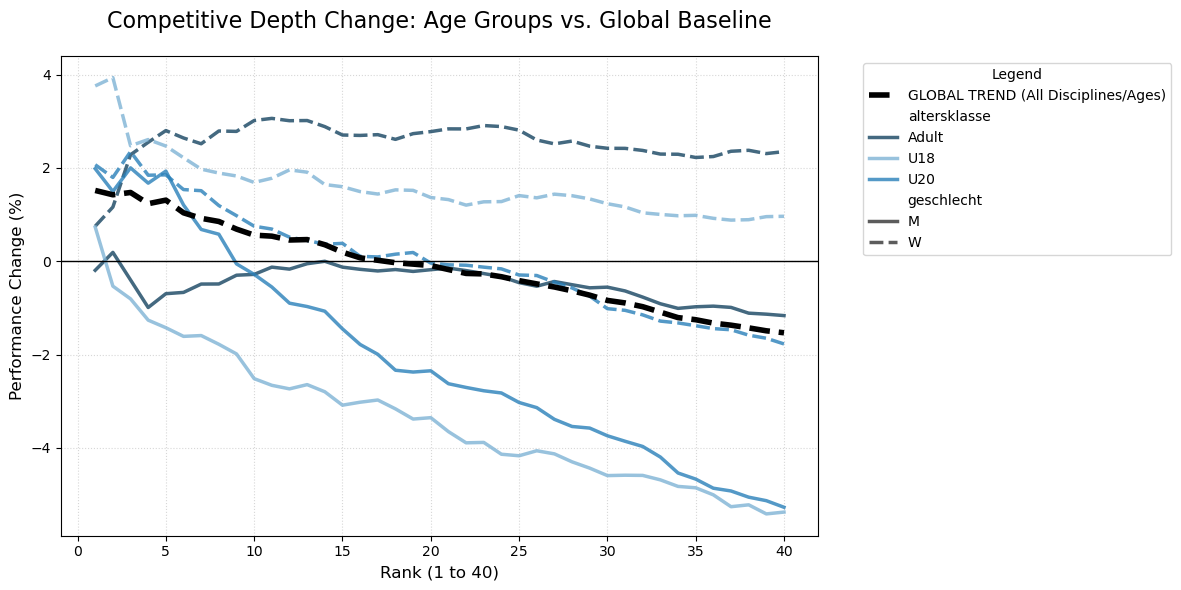

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# 1. Global Trend
sns.lineplot(
    data=results_ranks_all,
    x="rank", y="mean_diff_perc",
    color="black", linewidth=4, linestyle="--",
    label="GLOBAL TREND (All Disciplines/Ages)",
    zorder=5  # Keep it on top
)

# 2. Plot Age & Gender specific trends (results_ranks_age)
# This uses the data aggregated by age and gender across all disciplines
sns.lineplot(
    data=results_ranks_age, 
    x="rank", y="mean_diff_perc", 
    hue="altersklasse", 
    style="geschlecht",
    palette={"U18": "#7fb3d5", "U20": "#2980b9", "Adult": "#154360"},
    linewidth=2.5,
    alpha=0.8
)

# Formatting
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.title("Competitive Depth Change: Age Groups vs. Global Baseline", fontsize=16, pad=20)
plt.ylabel("Performance Change (%)", fontsize=12)
plt.xlabel("Rank (1 to 40)", fontsize=12)
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.legend(title="Legend", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

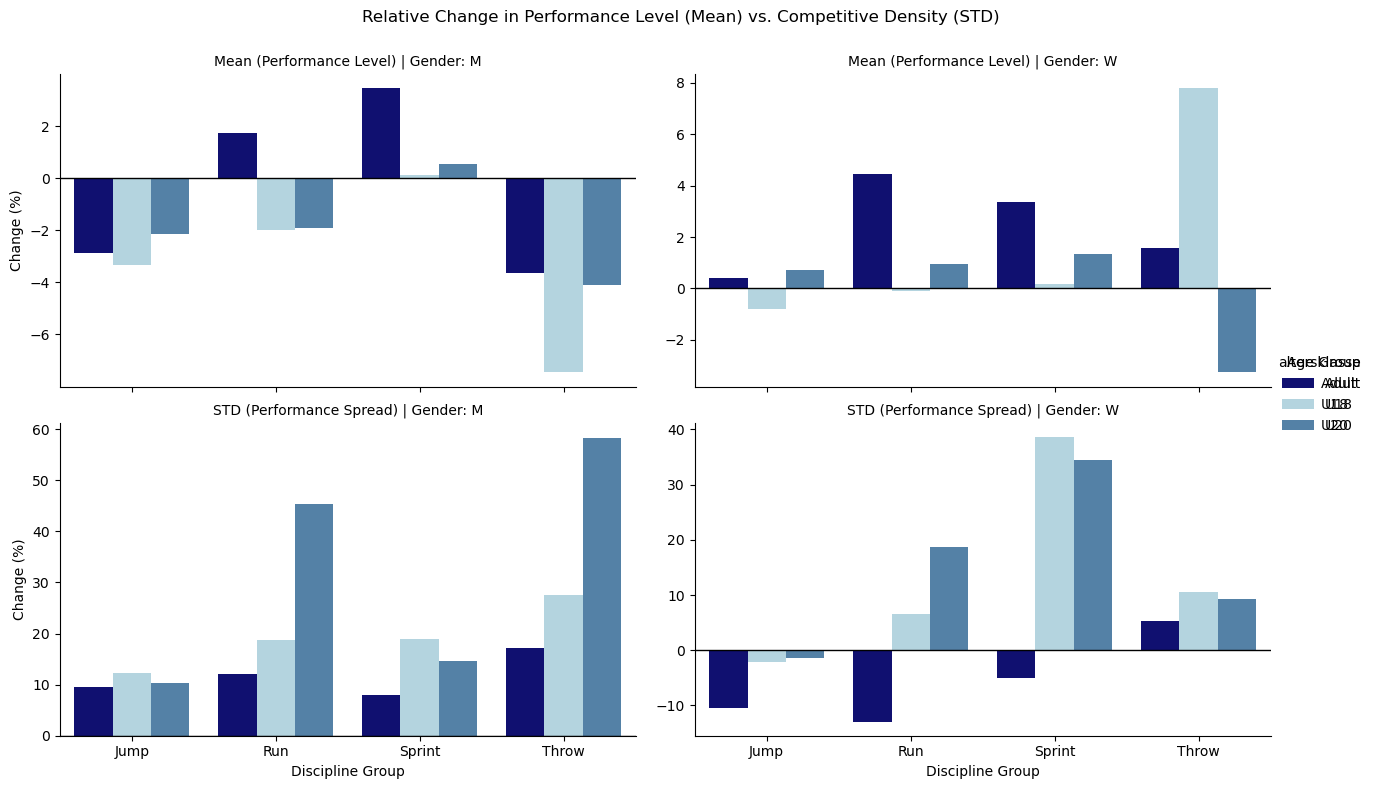

In [21]:
# 1. Melt the DataFrame to create a long format suitable for Seaborn
df_plot = results_std_mean.melt(
    id_vars=['Group', 'geschlecht', 'altersklasse'], 
    value_vars=['mean_diff_perc', 'std_diff_perc'],
    var_name='Metric', value_name='Change_Percent'
)

# 2. Rename for English labels
df_plot['Metric'] = df_plot['Metric'].replace({
    'mean_diff_perc': 'Mean (Performance Level)', 
    'std_diff_perc': 'STD (Performance Spread)'
})

# 3. Create the Plot
g = sns.catplot(
    data=df_plot, 
    x='Group', y='Change_Percent', 
    hue='altersklasse', col='geschlecht', row='Metric',
    kind='bar', 
    palette={"U18": "lightblue", "U20": "steelblue", "Adult": "navy"},
    height=4, aspect=1.5,
    sharey=False # Mean and STD have different scales
)

# 4. Styling
g.map(plt.axhline, y=0, color='black', linewidth=1)
g.set_titles("{row_name} | Gender: {col_name}")
g.set_axis_labels("Discipline Group", "Change (%)")
g.add_legend(title="Age Group")

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Relative Change in Performance Level (Mean) vs. Competitive Density (STD)')

plt.show()

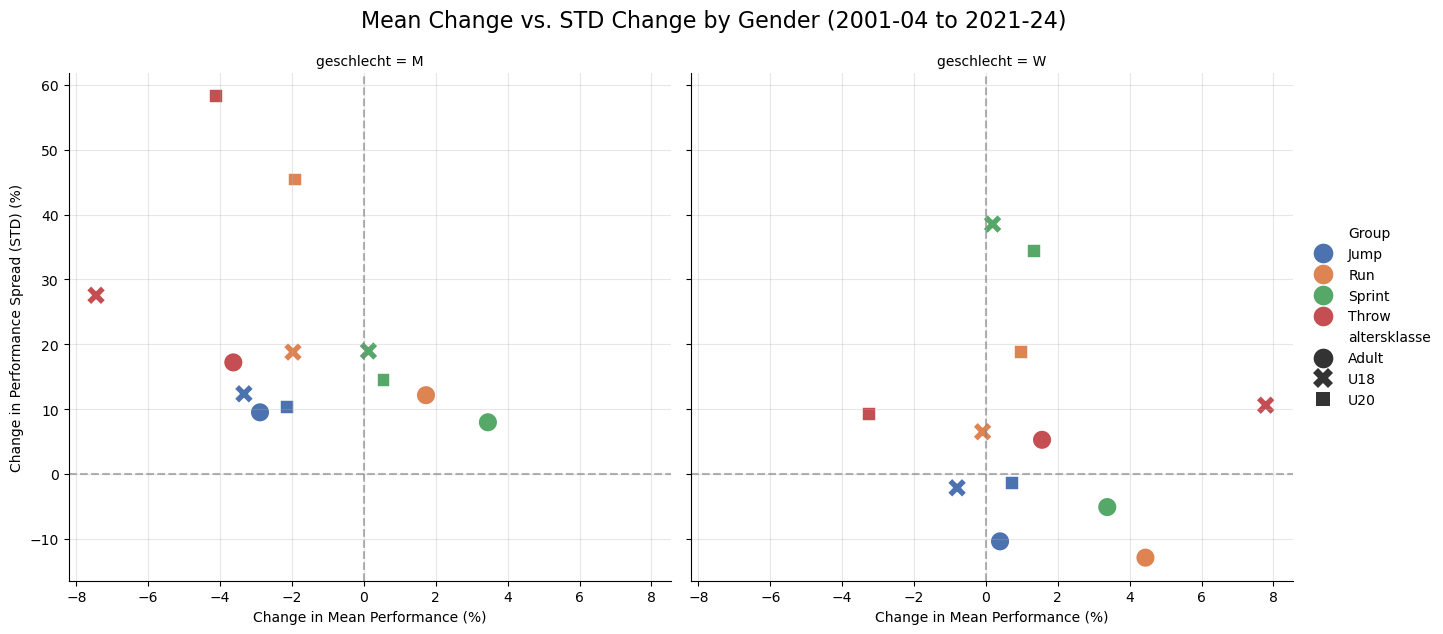

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Wir nutzen relplot für das automatische Faceting
g = sns.relplot(
    data=results_std_mean, 
    x='mean_diff_perc', y='std_diff_perc', 
    hue='Group', 
    style='altersklasse', 
    col='geschlecht',  # Erzeugt zwei Spalten (M/W)
    s=200, 
    height=6, aspect=1.1,
    palette="deep"
)

# Referenzlinien (0-Achsen) für jeden Subplot hinzufügen
for ax in g.axes.flat:
    ax.axhline(0, color='gray', linestyle='--', alpha=0.6)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.6)
    ax.grid(True, alpha=0.3)

# Titel und Beschriftung
g.set_axis_labels('Change in Mean Performance (%)', 'Change in Performance Spread (STD) (%)')
g.fig.suptitle('Mean Change vs. STD Change by Gender (2001-04 to 2021-24)', y=1.05, fontsize=16)

plt.show()

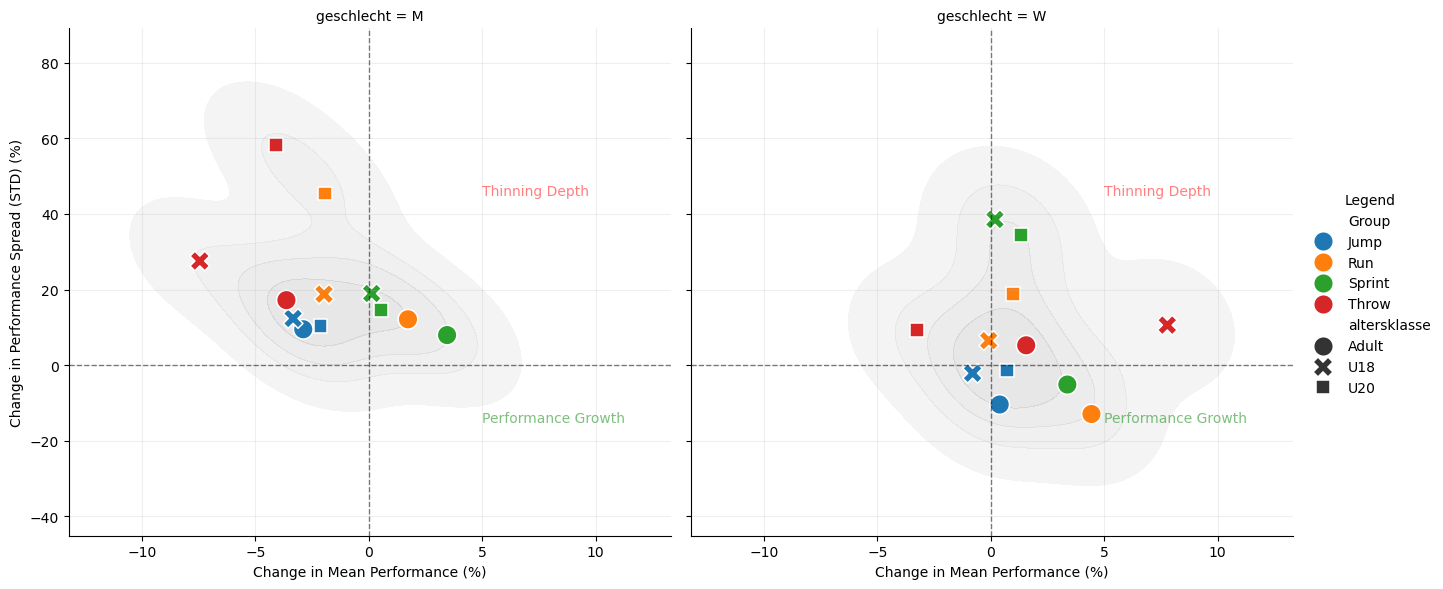

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the FacetGrid for Gender
g = sns.FacetGrid(results_std_mean, col="geschlecht", height=6, aspect=1.1)

# 1. Add the Density Contours first (in the background)
g.map_dataframe(sns.kdeplot, x='mean_diff_perc', y='std_diff_perc', 
                fill=True, alpha=0.15, levels=5, color="gray")

# 2. Add the individual Scatter points on top
g.map_dataframe(sns.scatterplot, x='mean_diff_perc', y='std_diff_perc', 
                hue='Group', style='altersklasse', s=200)

# 3. Add Reference Lines and Styling
for ax in g.axes.flat:
    ax.axhline(0, color='black', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(0, color='black', linestyle='--', alpha=0.5, linewidth=1)
    ax.grid(True, alpha=0.2)
    
    # Add Quadrant Labels for easier interpretation
    ax.text(5, 45, "Thinning Depth", color='red', alpha=0.5, fontsize=10)
    ax.text(5, -15, "Performance Growth", color='green', alpha=0.5, fontsize=10)

g.set_axis_labels('Change in Mean Performance (%)', 'Change in Performance Spread (STD) (%)')
g.add_legend(title="Legend")
plt.show()

In [33]:
results_all_subgroups = []

for (dis, gender, age), subgroup in top_raw_all.groupby(["disziplin", "geschlecht", "altersklasse"]):

    for event in subgroup['disziplin'].unique():
        subsub = subgroup[subgroup['disziplin'] == event]
        S_gr = subsub.pivot_table(index="jahr", columns="rank", values="iaaf_score")
        
        start = S_gr.loc[2001:2004].values.flatten()
        end = S_gr.loc[2021:2024].values.flatten()

        mean_diff = (np.mean(end) - np.mean(start)) / np.mean(start) * 100
        std_diff = (np.std(end) - np.std(start)) / np.std(start) * 100
        
        results_all_subgroups.append({
            "disziplin": dis,
            "geschlecht": gender,
            "altersklasse": age,
            "mean_diff_perc": mean_diff,
            "std_diff_perc": std_diff
        })

results_all_subgroups = pd.DataFrame(results_all_subgroups)

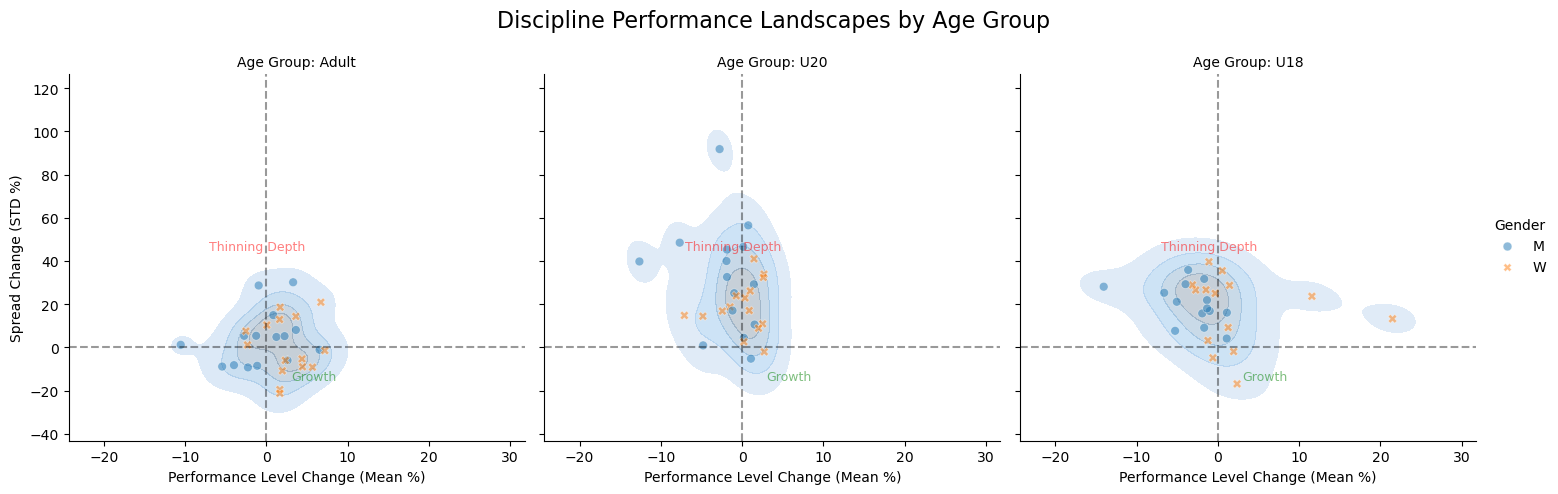

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the FacetGrid
# We order them Adult -> U20 -> U18 to show the logical progression
g = sns.FacetGrid(
    results_all_subgroups, 
    col="altersklasse", 
    col_order=["Adult", "U20", "U18"],
    height=5, 
    aspect=1,
    sharex=True, 
    sharey=True
)

# 2. Map the KDE (Density Cloud) to each subplot
g.map_dataframe(
    sns.kdeplot, 
    x='mean_diff_perc', 
    y='std_diff_perc',
    fill=True, 
    alpha=0.3, 
    levels=5, 
    thresh=0.1, 
    color="steelblue"
)

# 3. Map individual discipline points on top
g.map_dataframe(
    sns.scatterplot, 
    x='mean_diff_perc', 
    y='std_diff_perc', 
    hue='geschlecht', 
    style='geschlecht',
    alpha=0.5, 
    s=40
)

# 4. Add reference lines and labels to each plot
for ax in g.axes.flat:
    # 0-Reference lines
    ax.axhline(0, color='black', linestyle='--', alpha=0.4)
    ax.axvline(0, color='black', linestyle='--', alpha=0.4)
    
    # Optional: Visual "Quadrant" Hints
    ax.text(-7, 45, "Thinning Depth", color='red', alpha=0.5, fontsize=9)
    ax.text(3, -15, "Growth", color='green', alpha=0.5, fontsize=9)

# Final Styling
g.set_axis_labels("Performance Level Change (Mean %)", "Spread Change (STD %)")
g.set_titles(col_template="Age Group: {col_name}")
g.add_legend(title="Gender")

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Discipline Performance Landscapes by Age Group', fontsize=16)

plt.show()

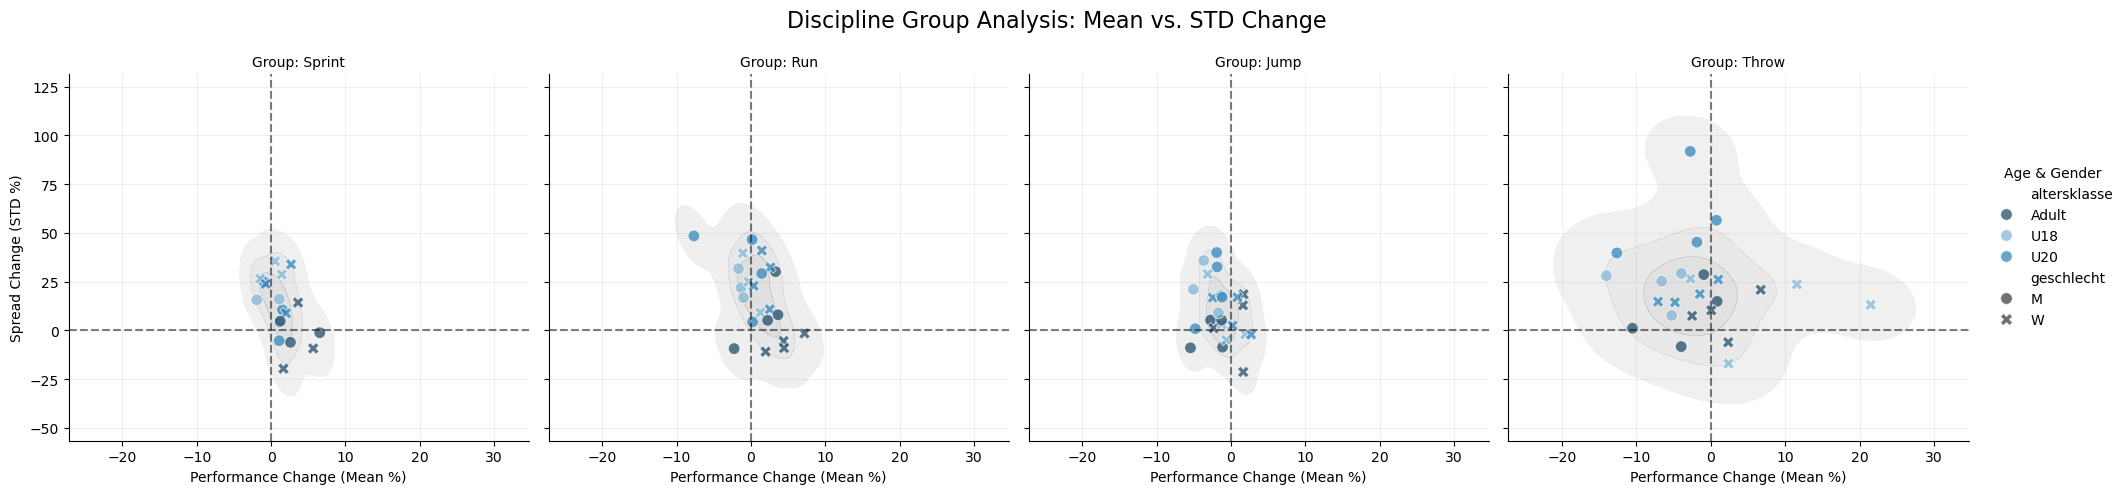

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Add the Group column to your dataframe
results_all_subgroups['Group'] = results_all_subgroups['disziplin'].map(mapping_dict)

# Drop any rows that didn't have a mapping (optional, for safety)
df_all = results_all_subgroups.dropna(subset=['Group'])
# 1. Initialize the FacetGrid
# We use 'Group' for columns to see the 4 categories side-by-side
g = sns.FacetGrid(
    results_all_subgroups, 
    col="Group", 
    col_order=['Sprint', 'Run', 'Jump', 'Throw'],
    height=5, 
    aspect=1,
    sharex=True, 
    sharey=True
)

# 2. Map the Density (KDE) to show the 'mass' of each group
g.map_dataframe(
    sns.kdeplot, 
    x='mean_diff_perc', 
    y='std_diff_perc',
    fill=True, 
    alpha=0.2, 
    levels=4, 
    color="gray"
)

# 3. Map the individual data points
# Hue by age group shows the 'drift' within that specific discipline
g.map_dataframe(
    sns.scatterplot, 
    x='mean_diff_perc', 
    y='std_diff_perc', 
    hue='altersklasse', 
    style='geschlecht',
    palette={"U18": "#7fb3d5", "U20": "#2980b9", "Adult": "#154360"},
    s=70,
    alpha=0.7
)

# 4. Styling and Reference Lines
for ax in g.axes.flat:
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.2)

g.set_axis_labels("Performance Change (Mean %)", "Spread Change (STD %)")
g.set_titles(col_template="Group: {col_name}")
g.add_legend(title="Age & Gender")

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Discipline Group Analysis: Mean vs. STD Change', fontsize=16)

plt.show()